In [1]:
# ============================================================
# 1. 导入库
# ============================================================

from pathlib import Path

import copy
import importlib
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from scipy import stats
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm


# 重新载入 modules.py，确保修改后立即生效
import modules
importlib.reload(modules)

from modules import MultiView


DTYPE = torch.float32
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")

PyTorch version: 2.7.0+cu128
Device: cuda


In [2]:
# ============================================================
# 2. 基础工具函数
# ============================================================

def set_seed(seed: int) -> None:
    """
    固定随机种子，尽量保证结果可复现。
    """
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def decode_matlab_string(value) -> str:
    """
    将 MATLAB cell/string 转换为普通 Python 字符串。
    """
    while isinstance(value, np.ndarray) and value.size == 1:
        value = value.reshape(-1)[0]

    if isinstance(value, bytes):
        return value.decode("utf-8", errors="replace").strip()

    if isinstance(value, np.ndarray):
        if value.dtype.kind in {"U", "S"}:
            return "".join(
                value.astype(str).reshape(-1)
            ).strip()

        return str(value.squeeze()).strip()

    return str(value).strip()


def load_voc_data(data_path):
    """
    读取 preprocessing_data.ipynb 生成的 MAT 文件。
    """
    data_path = Path(data_path)

    if not data_path.exists():
        raise FileNotFoundError(
            f"找不到数据文件：{data_path.resolve()}"
        )

    data = sio.loadmat(data_path)

    if "X" not in data:
        raise KeyError("MAT 文件中缺少 X。")

    if "y" not in data:
        raise KeyError("MAT 文件中缺少 y。")

    X = np.asarray(
        data["X"],
        dtype=np.float32,
    )

    y = np.asarray(
        data["y"],
        dtype=np.int64,
    ).reshape(-1)

    if X.ndim != 2:
        raise ValueError(
            f"X 必须是二维矩阵，当前形状：{X.shape}"
        )

    if len(y) != X.shape[0]:
        raise ValueError(
            "X 的样本数与 y 的标签数不一致。"
        )

    if not np.isfinite(X).all():
        raise ValueError(
            "X 中存在 NaN 或 Inf。"
        )

    unique_labels = np.unique(y)

    if not set(unique_labels.tolist()).issubset({0, 1}):
        raise ValueError(
            "当前 testing.ipynb 要求 y 已映射为 0/1。\n"
            f"实际标签为：{unique_labels.tolist()}\n"
            "不要在这里再次执行 y - 1。"
        )

    if len(unique_labels) != 2:
        raise ValueError(
            "数据中必须同时存在类别 0 和类别 1。"
        )

    if "feat_names" in data:
        voc_names = [
            decode_matlab_string(value)
            for value in data["feat_names"].reshape(-1)
        ]
    else:
        voc_names = [
            f"VOC_{index}"
            for index in range(X.shape[1])
        ]

    if len(voc_names) != X.shape[1]:
        print(
            "警告：feat_names 数量与 X 特征数不一致，"
            "将自动使用 VOC_0、VOC_1 等名称。"
        )

        voc_names = [
            f"VOC_{index}"
            for index in range(X.shape[1])
        ]

    print("数据读取完成")
    print("-" * 60)
    print(f"样本数：{X.shape[0]}")
    print(f"特征数：{X.shape[1]}")
    print(
        "类别数量：",
        dict(zip(*np.unique(y, return_counts=True))),
    )

    return X, y, voc_names

In [3]:
# ============================================================
# 3. DataLoader、类别权重和特征聚类
# ============================================================

def create_loader(
    X,
    y,
    batch_size,
    shuffle,
    seed,
    avoid_single_batch=True,
):
    """
    创建 PyTorch DataLoader。

    如果最后一个 batch 只有一个样本，则丢弃该 batch，
    避免某些含 BatchNorm 的网络报错。
    """
    X_tensor = torch.tensor(
        np.asarray(X),
        dtype=DTYPE,
    )

    y_tensor = torch.tensor(
        np.asarray(y),
        dtype=torch.long,
    )

    dataset = TensorDataset(
        X_tensor,
        y_tensor,
    )

    drop_last = False

    if (
        shuffle
        and avoid_single_batch
        and len(dataset) > batch_size
        and len(dataset) % batch_size == 1
    ):
        drop_last = True

    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        generator=generator if shuffle else None,
    )


def compute_class_weights(y_train):
    """
    根据训练集类别数量计算交叉熵类别权重。
    """
    counts = np.bincount(
        np.asarray(y_train, dtype=int),
        minlength=2,
    ).astype(np.float64)

    if np.any(counts == 0):
        raise ValueError(
            f"训练集存在空类别：{counts.tolist()}"
        )

    weights = counts.sum() / (
        2.0 * counts
    )

    return torch.tensor(
        weights,
        dtype=DTYPE,
        device=DEVICE,
    )


def feature_cluster_local(
    X_train,
    num_cluster,
    random_state,
):
    """
    对特征进行 KMeans 聚类。

    X_train:
        形状为 [样本数, 特征数]

    输出：
        [聚类数, 特征数] 的 one-hot 矩阵
    """
    n_features = X_train.shape[1]

    if num_cluster < 1:
        raise ValueError(
            "num_cluster 必须大于等于 1。"
        )

    if num_cluster > n_features:
        raise ValueError(
            f"num_cluster={num_cluster} 大于特征数 {n_features}。"
        )

    kmeans = KMeans(
        n_clusters=num_cluster,
        n_init=20,
        random_state=random_state,
    )

    cluster_ids = kmeans.fit_predict(
        X_train.T
    )

    cluster_ids = torch.tensor(
        cluster_ids,
        dtype=torch.long,
    )

    cluster_mask = F.one_hot(
        cluster_ids,
        num_classes=num_cluster,
    ).T.contiguous()

    return cluster_mask

In [4]:
# ============================================================
# 4. 指标计算与验证集阈值选择
# ============================================================

def compute_metrics(
    targets,
    predictions,
    probabilities,
):
    targets = np.asarray(
        targets,
        dtype=int,
    )

    predictions = np.asarray(
        predictions,
        dtype=int,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    cm = confusion_matrix(
        targets,
        predictions,
        labels=[0, 1],
    )

    tn, fp, fn, tp = cm.ravel()

    eps = 1e-12

    sensitivity = tp / (
        tp + fn + eps
    )

    specificity = tn / (
        tn + fp + eps
    )

    ppv = tp / (
        tp + fp + eps
    )

    npv = tn / (
        tn + fn + eps
    )

    accuracy = accuracy_score(
        targets,
        predictions,
    )

    f1 = f1_score(
        targets,
        predictions,
        zero_division=0,
    )

    balanced_acc = balanced_accuracy_score(
        targets,
        predictions,
    )

    try:
        auc_value = roc_auc_score(
            targets,
            probabilities,
        )
    except ValueError:
        auc_value = np.nan

    return {
        "Sensitivity": float(sensitivity),
        "Specificity": float(specificity),
        "PPV": float(ppv),
        "NPV": float(npv),
        "Accuracy": float(accuracy),
        "Balanced_Accuracy": float(balanced_acc),
        "F1": float(f1),
        "AUC": float(auc_value),
    }, cm


def select_validation_threshold(
    targets,
    probabilities,
    threshold_min=0.10,
    threshold_max=0.90,
    threshold_step=0.01,
):
    """
    在验证集上选择分类阈值。

    主目标是让 ACC 和 F1 中较低的一个尽量高，
    避免只提高 ACC 而牺牲 F1。
    """
    targets = np.asarray(
        targets,
        dtype=int,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    thresholds = np.arange(
        threshold_min,
        threshold_max + threshold_step / 2,
        threshold_step,
    )

    best_result = None

    for threshold in thresholds:
        predictions = (
            probabilities >= threshold
        ).astype(int)

        metrics, cm = compute_metrics(
            targets,
            predictions,
            probabilities,
        )

        # 直接优化 ACC 与 F1 中较低的一项
        joint_score = min(
            metrics["Accuracy"],
            metrics["F1"],
        )

        # 用于分数相同时继续比较
        secondary_score = (
            metrics["Accuracy"]
            + metrics["F1"]
            + metrics["Balanced_Accuracy"]
        ) / 3.0

        candidate = {
            "threshold": float(threshold),
            "joint_score": float(joint_score),
            "secondary_score": float(secondary_score),
            "metrics": metrics,
            "cm": cm,
        }

        if best_result is None:
            best_result = candidate
            continue

        better_primary = (
            candidate["joint_score"]
            > best_result["joint_score"] + 1e-12
        )

        equal_primary = np.isclose(
            candidate["joint_score"],
            best_result["joint_score"],
        )

        better_secondary = (
            candidate["secondary_score"]
            > best_result["secondary_score"] + 1e-12
        )

        if better_primary or (
            equal_primary and better_secondary
        ):
            best_result = candidate

    return best_result


def mean_ci(values, alpha=0.05):
    """
    均值、标准差、标准误和 t 分布 95% CI。
    """
    values = np.asarray(
        values,
        dtype=float,
    )

    values = values[
        ~np.isnan(values)
    ]

    n = len(values)

    if n == 0:
        return (
            np.nan,
            np.nan,
            np.nan,
            np.nan,
            np.nan,
        )

    mean_value = float(
        values.mean()
    )

    if n < 2:
        return (
            mean_value,
            np.nan,
            np.nan,
            np.nan,
            np.nan,
        )

    std_value = float(
        values.std(ddof=1)
    )

    sem_value = std_value / np.sqrt(n)

    t_critical = stats.t.ppf(
        1 - alpha / 2,
        df=n - 1,
    )

    lower = mean_value - (
        t_critical * sem_value
    )

    upper = mean_value + (
        t_critical * sem_value
    )

    return (
        mean_value,
        std_value,
        sem_value,
        lower,
        upper,
    )

In [5]:
# ============================================================
# 5. 统一处理模型输出的特征掩码
# ============================================================

def to_feature_vector(
    values,
    n_features,
    binary=False,
):
    """
    将模型返回的 mask 或 soft score 统一转换为一维特征向量。
    """
    if not torch.is_tensor(values):
        values = torch.tensor(
            values,
            dtype=DTYPE,
        )

    values = values.detach()


    while values.ndim > 1 and 1 in values.shape:
        values = values.squeeze()

    if values.ndim == 2:
        if values.shape[-1] == n_features:
            values = values.mean(dim=0)

        elif values.shape[0] == n_features:
            values = values.mean(dim=1)

    values = values.reshape(-1)

    if values.numel() != n_features:
        raise ValueError(
            "模型返回的特征掩码长度不正确。\n"
            f"预期长度：{n_features}\n"
            f"实际长度：{values.numel()}\n"
            f"原始形状：{tuple(values.shape)}"
        )

    values = values.to(
        dtype=DTYPE,
    )

    if binary:
        values = (
            values > 0.5
        ).float()

    return values

In [6]:
# ============================================================
# 6. 使用指定 mask 进行预测
# ============================================================

def predict_probabilities(
    model,
    loader,
    feature_mask,
):
    model.eval()

    feature_mask = feature_mask.to(
        DEVICE,
        dtype=DTYPE,
    )

    all_probabilities = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(
                DEVICE,
                dtype=DTYPE,
            )

            logits = model.mlp_classifier(
                X_batch * feature_mask
            )

            probabilities = torch.softmax(
                logits.float(),
                dim=1,
            )[:, 1]

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

            all_targets.extend(
                y_batch.numpy()
            )

    return (
        np.asarray(
            all_probabilities,
            dtype=float,
        ),
        np.asarray(
            all_targets,
            dtype=int,
        ),
    )

In [7]:
# ============================================================
# 7. 训练一个候选模型
# ============================================================

def train_one_candidate(
    X_train,
    y_train,
    X_val,
    y_val,
    k_mean_mask,
    run_seed,
    batch_size,
    epochs,
    num_blocks,
    head_dim,
    learning_rate_logist,
    learning_rate_classifier,
    weight_decay_logist,
    weight_decay_classifier,
    sparsity_lambda,
    temp_start,
    temp_end,
    patience,
):
    set_seed(run_seed)

    n_features = X_train.shape[1]

    train_loader = create_loader(
        X=X_train,
        y=y_train,
        batch_size=batch_size,
        shuffle=True,
        seed=run_seed,
    )

    val_loader = create_loader(
        X=X_val,
        y=y_val,
        batch_size=batch_size,
        shuffle=False,
        seed=run_seed,
        avoid_single_batch=False,
    )

    X_val_tensor = torch.tensor(
        X_val,
        dtype=DTYPE,
        device=DEVICE,
    )

    model = MultiView(
        k_mean_mask=k_mean_mask,
        num_blocks=num_blocks,
        head_dim=head_dim,
        num_class=2,
        temperature=temp_start,
    ).to(
        DEVICE,
        dtype=DTYPE,
    )

    optimizer = optim.AdamW(
        [
            {
                "params": model.logist.parameters(),
                "lr": learning_rate_logist,
                "weight_decay": weight_decay_logist,
            },
            {
                "params": model.mlp_classifier.parameters(),
                "lr": learning_rate_classifier,
                "weight_decay": weight_decay_classifier,
            },
        ]
    )

    class_weights = compute_class_weights(
        y_train
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=10,
        min_lr=1e-6,
    )

    best_result = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.temperature = (
            temp_start
            + (temp_end - temp_start)
            * epoch
            / max(1, epochs - 1)
        )

        model.train()

        epoch_loss = 0.0
        epoch_samples = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(
                DEVICE,
                dtype=DTYPE,
            )

            y_batch = y_batch.to(
                DEVICE,
                dtype=torch.long,
            )

            optimizer.zero_grad()

            logits, _ = model(
                X_batch
            )

            soft_selection = model.selection_prob(
                X_batch
            )

            classification_loss = criterion(
                logits,
                y_batch,
            )

            sparsity_loss = soft_selection.mean()

            loss = (
                classification_loss
                + sparsity_lambda
                * sparsity_loss
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0,
            )

            optimizer.step()

            epoch_loss += (
                loss.item()
                * y_batch.size(0)
            )

            epoch_samples += y_batch.size(0)

        model.eval()

        with torch.no_grad():
            raw_mask = model.get_score(
                X_val_tensor
            )

            binary_mask = to_feature_vector(
                raw_mask,
                n_features=n_features,
                binary=True,
            )

            raw_soft_score = model.selection_prob(
                X_val_tensor
            )

            soft_score = to_feature_vector(
                raw_soft_score,
                n_features=n_features,
                binary=False,
            )

        val_probabilities, val_targets = predict_probabilities(
            model=model,
            loader=val_loader,
            feature_mask=binary_mask,
        )

        threshold_result = select_validation_threshold(
            targets=val_targets,
            probabilities=val_probabilities,
        )

        val_metrics = threshold_result["metrics"]

        val_joint_score = threshold_result[
            "joint_score"
        ]

        scheduler.step(
            val_joint_score
        )

        current_result = {
            "epoch": epoch + 1,
            "state_dict": {
                key: value.detach().cpu().clone()
                for key, value
                in model.state_dict().items()
            },
            "binary_mask": (
                binary_mask.detach()
                .cpu()
                .clone()
            ),
            "soft_score": (
                soft_score.detach()
                .cpu()
                .clone()
            ),
            "threshold": threshold_result[
                "threshold"
            ],
            "joint_score": val_joint_score,
            "val_metrics": val_metrics,
            "train_loss": (
                epoch_loss
                / max(epoch_samples, 1)
            ),
        }

        should_update = False

        if best_result is None:
            should_update = True

        elif (
            current_result["joint_score"]
            > best_result["joint_score"] + 1e-12
        ):
            should_update = True

        elif np.isclose(
            current_result["joint_score"],
            best_result["joint_score"],
        ):
            current_secondary = (
                current_result["val_metrics"]["Accuracy"]
                + current_result["val_metrics"]["F1"]
                + current_result["val_metrics"]["AUC"]
            )

            best_secondary = (
                best_result["val_metrics"]["Accuracy"]
                + best_result["val_metrics"]["F1"]
                + best_result["val_metrics"]["AUC"]
            )

            if current_secondary > best_secondary:
                should_update = True

        if should_update:
            best_result = current_result
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (
            patience is not None
            and epochs_without_improvement >= patience
        ):
            break

    if best_result is None:
        raise RuntimeError(
            "训练没有产生有效模型。"
        )

    return best_result

In [8]:
# ============================================================
# 8. 完整重复实验
# ============================================================

def experiment(
    data_path,
    output_dir,
    num_cluster=3,
    experiment_repeats=5,
    repeats=3,
    epochs=150,
    batch_size=16,
    outer_test_size=0.20,
    inner_val_size=0.25,
    num_blocks=2,
    head_dim=64,
    learning_rate_logist=1e-4,
    learning_rate_classifier=3e-4,
    weight_decay_logist=1e-4,
    weight_decay_classifier=1e-3,
    sparsity_lambda=1e-3,
    temp_start=1.0,
    temp_end=0.5,
    patience=40,
    seed=42,
    panel_threshold=0.5,
):
    output_dir = Path(
        output_dir
    )

    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    checkpoint_dir = (
        output_dir / "checkpoints"
    )

    checkpoint_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    X, y, voc_names = load_voc_data(
        data_path
    )

    n_samples, n_features = X.shape

    all_indices = np.arange(
        n_samples
    )

    all_masks = []
    all_soft_scores = []
    all_confusion_matrices = []
    all_probabilities = []
    all_targets = []
    all_metrics = []

    progress = tqdm(
        range(experiment_repeats),
        desc="Outer repeats",
    )

    for outer_repeat in progress:
        outer_seed = (
            seed
            + outer_repeat * 1000
        )

        set_seed(
            outer_seed
        )

        outer_train_indices, test_indices = train_test_split(
            all_indices,
            test_size=outer_test_size,
            random_state=outer_seed,
            stratify=y,
        )

        inner_train_indices, val_indices = train_test_split(
            outer_train_indices,
            test_size=inner_val_size,
            random_state=outer_seed + 1,
            stratify=y[outer_train_indices],
        )

        # 只能在内层训练集拟合标准化器
        scaler = StandardScaler()

        X_inner_train = scaler.fit_transform(
            X[inner_train_indices]
        ).astype(np.float32)

        X_val = scaler.transform(
            X[val_indices]
        ).astype(np.float32)

        X_test = scaler.transform(
            X[test_indices]
        ).astype(np.float32)

        y_inner_train = y[
            inner_train_indices
        ]

        y_val = y[
            val_indices
        ]

        y_test = y[
            test_indices
        ]

        k_mean_mask = feature_cluster_local(
            X_train=X_inner_train,
            num_cluster=num_cluster,
            random_state=outer_seed,
        )

        group_best = None

        # 同一 train/val 划分下，重复不同模型初始化
        for inner_repeat in range(repeats):
            candidate_seed = (
                outer_seed
                + inner_repeat
                + 10
            )

            candidate = train_one_candidate(
                X_train=X_inner_train,
                y_train=y_inner_train,
                X_val=X_val,
                y_val=y_val,
                k_mean_mask=k_mean_mask,
                run_seed=candidate_seed,
                batch_size=batch_size,
                epochs=epochs,
                num_blocks=num_blocks,
                head_dim=head_dim,
                learning_rate_logist=learning_rate_logist,
                learning_rate_classifier=learning_rate_classifier,
                weight_decay_logist=weight_decay_logist,
                weight_decay_classifier=weight_decay_classifier,
                sparsity_lambda=sparsity_lambda,
                temp_start=temp_start,
                temp_end=temp_end,
                patience=patience,
            )

            if group_best is None:
                group_best = candidate
                continue

            candidate_joint = candidate[
                "joint_score"
            ]

            best_joint = group_best[
                "joint_score"
            ]

            if candidate_joint > best_joint + 1e-12:
                group_best = candidate

            elif np.isclose(
                candidate_joint,
                best_joint,
            ):
                candidate_f1 = candidate[
                    "val_metrics"
                ]["F1"]

                best_f1 = group_best[
                    "val_metrics"
                ]["F1"]

                if candidate_f1 > best_f1:
                    group_best = candidate

        if group_best is None:
            raise RuntimeError(
                f"第 {outer_repeat} 组没有有效模型。"
            )

        # 恢复本组最佳模型
        best_model = MultiView(
            k_mean_mask=k_mean_mask,
            num_blocks=num_blocks,
            head_dim=head_dim,
            num_class=2,
            temperature=temp_end,
        ).to(
            DEVICE,
            dtype=DTYPE,
        )

        best_model.load_state_dict(
            group_best["state_dict"]
        )

        best_model.eval()

        test_loader = create_loader(
            X=X_test,
            y=y_test,
            batch_size=batch_size,
            shuffle=False,
            seed=outer_seed,
            avoid_single_batch=False,
        )

        test_probabilities, test_targets = predict_probabilities(
            model=best_model,
            loader=test_loader,
            feature_mask=group_best[
                "binary_mask"
            ],
        )

        test_predictions = (
            test_probabilities
            >= group_best["threshold"]
        ).astype(int)

        test_metrics, test_cm = compute_metrics(
            targets=test_targets,
            predictions=test_predictions,
            probabilities=test_probabilities,
        )

        row = {
            "Repeat": outer_repeat,
            "Seed": outer_seed,
            "Best_Epoch": group_best[
                "epoch"
            ],
            "Threshold": group_best[
                "threshold"
            ],
            "Selected_Features": int(
                group_best[
                    "binary_mask"
                ].sum().item()
            ),
            "Val_Accuracy": group_best[
                "val_metrics"
            ]["Accuracy"],
            "Val_F1": group_best[
                "val_metrics"
            ]["F1"],
            "Val_AUC": group_best[
                "val_metrics"
            ]["AUC"],
            "Val_Joint": group_best[
                "joint_score"
            ],
        }

        row.update(
            test_metrics
        )

        all_metrics.append(
            row
        )

        all_masks.append(
            group_best[
                "binary_mask"
            ].float().cpu()
        )

        all_soft_scores.append(
            group_best[
                "soft_score"
            ].float().cpu().numpy()
        )

        all_confusion_matrices.append(
            test_cm
        )

        all_probabilities.append(
            test_probabilities
        )

        all_targets.append(
            test_targets
        )

        checkpoint = {
            "state_dict": group_best[
                "state_dict"
            ],
            "binary_mask": group_best[
                "binary_mask"
            ],
            "soft_score": group_best[
                "soft_score"
            ],
            "threshold": group_best[
                "threshold"
            ],
            "val_metrics": group_best[
                "val_metrics"
            ],
            "test_metrics": test_metrics,
            "scaler_mean": scaler.mean_,
            "scaler_scale": scaler.scale_,
            "k_mean_mask": k_mean_mask,
            "train_indices": inner_train_indices,
            "val_indices": val_indices,
            "test_indices": test_indices,
            "seed": outer_seed,
        }

        checkpoint_path = (
            checkpoint_dir
            / f"champion_model_repeat_{outer_repeat:03d}.pt"
        )

        torch.save(
            checkpoint,
            checkpoint_path,
        )

        progress.set_postfix(
            {
                "ACC": f"{test_metrics['Accuracy']:.3f}",
                "F1": f"{test_metrics['F1']:.3f}",
                "AUC": f"{test_metrics['AUC']:.3f}",
            }
        )

    # ========================================================
    # 汇总特征选择
    # ========================================================

    all_masks_tensor = torch.stack(
        all_masks,
        dim=0,
    )

    all_soft_array = np.stack(
        all_soft_scores,
        axis=0,
    )

    selection_frequency = (
        all_masks_tensor
        .mean(dim=0)
        .numpy()
    )

    soft_mean = all_soft_array.mean(
        axis=0
    )

    soft_std = all_soft_array.std(
        axis=0,
        ddof=1 if experiment_repeats > 1 else 0,
    )

    soft_sem = soft_std / np.sqrt(
        experiment_repeats
    )

    torch.save(
        all_masks_tensor,
        output_dir / "all_binary_masks.pt",
    )

    feature_df = pd.DataFrame(
        {
            "VOC_Index": np.arange(
                n_features
            ),
            "VOC_Name": voc_names,
            "Selection_Frequency": selection_frequency,
            "Soft_Mean": soft_mean,
            "Soft_Std": soft_std,
            "Soft_SEM": soft_sem,
        }
    )

    feature_df = feature_df.sort_values(
        [
            "Selection_Frequency",
            "Soft_Mean",
        ],
        ascending=False,
    ).reset_index(drop=True)

    feature_df.to_csv(
        output_dir
        / "feature_selection_stats.csv",
        index=False,
        encoding="utf-8-sig",
    )

    panel_df = feature_df[
        feature_df["Selection_Frequency"]
        >= panel_threshold
    ].copy()

    panel_df.to_csv(
        output_dir
        / "selected_voc_panel.csv",
        index=False,
        encoding="utf-8-sig",
    )

    # ========================================================
    # 保存每组指标与汇总指标
    # ========================================================

    per_repeat_df = pd.DataFrame(
        all_metrics
    )

    per_repeat_df.to_csv(
        output_dir
        / "metrics_per_repeat.csv",
        index=False,
        encoding="utf-8-sig",
    )

    metric_keys = [
        "Sensitivity",
        "Specificity",
        "PPV",
        "NPV",
        "Accuracy",
        "Balanced_Accuracy",
        "F1",
        "AUC",
    ]

    summary_rows = []

    for metric_name in metric_keys:
        mean_value, std_value, sem_value, lower, upper = mean_ci(
            per_repeat_df[
                metric_name
            ].values
        )

        summary_rows.append(
            {
                "Metric": metric_name,
                "Mean": mean_value,
                "Std": std_value,
                "SEM": sem_value,
                "CI95_Lower": lower,
                "CI95_Upper": upper,
            }
        )

    summary_df = pd.DataFrame(
        summary_rows
    )

    summary_df.to_csv(
        output_dir
        / "metrics_summary.csv",
        index=False,
        encoding="utf-8-sig",
    )

    # ========================================================
    # 混淆矩阵汇总
    # ========================================================

    all_cm_array = np.stack(
        all_confusion_matrices,
        axis=0,
    )

    cm_mean = all_cm_array.mean(
        axis=0
    )

    cm_df = pd.DataFrame(
        cm_mean,
        index=[
            "True_Negative",
            "True_Positive",
        ],
        columns=[
            "Pred_Negative",
            "Pred_Positive",
        ],
    )

    cm_df.to_csv(
        output_dir
        / "confusion_matrix_summary.csv",
        encoding="utf-8-sig",
    )

    # ========================================================
    # ROC 数据
    # ========================================================

    mean_fpr = np.linspace(
        0,
        1,
        200,
    )

    interpolated_tprs = []
    auc_values = []

    for probabilities, targets in zip(
        all_probabilities,
        all_targets,
    ):
        if len(np.unique(targets)) < 2:
            continue

        fpr, tpr, _ = roc_curve(
            targets,
            probabilities,
        )

        auc_value = auc(
            fpr,
            tpr,
        )

        interpolated_tpr = np.interp(
            mean_fpr,
            fpr,
            tpr,
        )

        interpolated_tpr[0] = 0.0
        interpolated_tpr[-1] = 1.0

        interpolated_tprs.append(
            interpolated_tpr
        )

        auc_values.append(
            auc_value
        )

    interpolated_tprs = np.asarray(
        interpolated_tprs
    )

    auc_values = np.asarray(
        auc_values
    )

    if len(interpolated_tprs) == 0:
        raise RuntimeError(
            "没有可用于绘制 ROC 的有效测试结果。"
        )

    mean_tpr = interpolated_tprs.mean(
        axis=0
    )

    std_tpr = interpolated_tprs.std(
        axis=0
    )

    mean_tpr[-1] = 1.0

    mean_auc = float(
        auc_values.mean()
    )

    std_auc = float(
        auc_values.std()
    )

    np.savez(
        output_dir / "plot_data.npz",
        voc_names=np.asarray(
            voc_names,
            dtype=object,
        ),
        selection_frequency=selection_frequency,
        soft_mean=soft_mean,
        soft_std=soft_std,
        soft_sem=soft_sem,
        mean_fpr=mean_fpr,
        interpolated_tprs=interpolated_tprs,
        mean_tpr=mean_tpr,
        std_tpr=std_tpr,
        auc_values=auc_values,
        mean_auc=mean_auc,
        std_auc=std_auc,
        cm_mean=cm_mean,
    )

    np.savez(
        output_dir
        / "raw_probs_targets.npz",
        probabilities=np.asarray(
            all_probabilities,
            dtype=object,
        ),
        targets=np.asarray(
            all_targets,
            dtype=object,
        ),
    )

    pd.DataFrame(
        {
            "Repeat": np.arange(
                len(auc_values)
            ),
            "AUC": auc_values,
        }
    ).to_csv(
        output_dir
        / "auc_per_repeat.csv",
        index=False,
    )

    # ========================================================
    # 保存运行配置
    # ========================================================

    config = {
        "data_path": str(data_path),
        "output_dir": str(output_dir),
        "seed": seed,
        "device": str(DEVICE),
        "num_samples": n_samples,
        "num_features": n_features,
        "num_cluster": num_cluster,
        "experiment_repeats": experiment_repeats,
        "repeats": repeats,
        "epochs": epochs,
        "batch_size": batch_size,
        "outer_test_size": outer_test_size,
        "inner_val_size": inner_val_size,
        "num_blocks": num_blocks,
        "head_dim": head_dim,
        "learning_rate_logist": learning_rate_logist,
        "learning_rate_classifier": learning_rate_classifier,
        "weight_decay_logist": weight_decay_logist,
        "weight_decay_classifier": weight_decay_classifier,
        "sparsity_lambda": sparsity_lambda,
        "temp_start": temp_start,
        "temp_end": temp_end,
        "patience": patience,
        "panel_threshold": panel_threshold,
        "torch_version": torch.__version__,
        "numpy_version": np.__version__,
    }

    with open(
        output_dir / "run_config.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            config,
            file,
            ensure_ascii=False,
            indent=2,
        )

    # ========================================================
    # 图 1：特征重要性
    # ========================================================

    selected_count = int(
        np.sum(
            selection_frequency
            >= panel_threshold
        )
    )

    if selected_count > 0:
        top_n = min(
            selected_count,
            50,
        )
    else:
        top_n = min(
            20,
            n_features,
        )

    top_indices = np.lexsort(
        (
            soft_mean,
            selection_frequency,
        )
    )[::-1][:top_n]

    top_names = [
        voc_names[index]
        for index in top_indices
    ]

    figure_1, axes = plt.subplots(
        2,
        1,
        figsize=(16, 9),
    )

    axes[0].bar(
        np.arange(top_n),
        selection_frequency[
            top_indices
        ],
        alpha=0.75,
    )

    axes[0].axhline(
        panel_threshold,
        linestyle="--",
        label=f"Threshold = {panel_threshold}",
    )

    axes[0].set_ylabel(
        "Selection frequency"
    )

    axes[0].set_ylim(
        0,
        1.05,
    )

    axes[0].set_title(
        f"Top {top_n} VOC selection frequency"
    )

    axes[0].legend()

    axes[1].bar(
        np.arange(top_n),
        soft_mean[top_indices],
        alpha=0.70,
        label="Mean soft importance",
    )

    axes[1].errorbar(
        np.arange(top_n),
        soft_mean[top_indices],
        yerr=soft_sem[top_indices],
        fmt="none",
        capsize=2,
        label="SEM",
    )

    axes[1].set_ylabel(
        "Soft importance"
    )

    axes[1].set_xlabel(
        "VOC feature"
    )

    axes[1].set_title(
        "Soft feature importance"
    )

    axes[1].legend()

    if top_n <= 30:
        axes[1].set_xticks(
            np.arange(top_n)
        )

        axes[1].set_xticklabels(
            top_names,
            rotation=90,
            fontsize=7,
        )

    figure_1.tight_layout()

    figure_1.savefig(
        output_dir
        / "feature_importance.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    # ========================================================
    # 图 2：ROC
    # ========================================================

    figure_2, axis = plt.subplots(
        figsize=(7, 7)
    )

    for current_tpr in interpolated_tprs:
        axis.plot(
            mean_fpr,
            current_tpr,
            alpha=0.12,
            linewidth=0.8,
        )

    axis.plot(
        mean_fpr,
        mean_tpr,
        linewidth=2,
        label=(
            f"Mean ROC "
            f"(AUC = {mean_auc:.3f} "
            f"± {std_auc:.3f})"
        ),
    )

    axis.fill_between(
        mean_fpr,
        np.maximum(
            mean_tpr - std_tpr,
            0,
        ),
        np.minimum(
            mean_tpr + std_tpr,
            1,
        ),
        alpha=0.20,
        label="±1 SD",
    )

    axis.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
        label="Chance",
    )

    axis.set_xlim(
        0,
        1,
    )

    axis.set_ylim(
        0,
        1.02,
    )

    axis.set_xlabel(
        "False Positive Rate"
    )

    axis.set_ylabel(
        "True Positive Rate"
    )

    axis.set_title(
        f"Repeated holdout ROC "
        f"(n={experiment_repeats})"
    )

    axis.legend(
        loc="lower right"
    )

    figure_2.tight_layout()

    figure_2.savefig(
        output_dir
        / "roc_curve.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    # ========================================================
    # 最终报告
    # ========================================================

    print("\n" + "=" * 72)
    print(
        f"Final report: "
        f"{experiment_repeats} repeated holdout experiments"
    )
    print("-" * 72)
    print(
        f"{'Metric':<20}"
        f"{'Mean':>10}"
        f"{'95% CI':>28}"
    )

    for _, result_row in summary_df.iterrows():
        confidence_interval = (
            f"[{result_row['CI95_Lower']:.3f}, "
            f"{result_row['CI95_Upper']:.3f}]"
        )

        print(
            f"{result_row['Metric']:<20}"
            f"{result_row['Mean']:>10.3f}"
            f"{confidence_interval:>28}"
        )

    print("-" * 72)
    print(
        f"平均入选特征数："
        f"{per_repeat_df['Selected_Features'].mean():.1f}"
    )
    print(
        f"最终稳定 VOC 数："
        f"{len(panel_df)}"
    )
    print(
        f"结果目录："
        f"{output_dir.resolve()}"
    )
    print("=" * 72)

    return (
        summary_df,
        per_repeat_df,
        feature_df,
        panel_df,
    )

summary_003, repeat_003, feature_003, panel_003 = experiment(
    data_path="./data/voc_dataset_1+2_vs_3.mat",
    output_dir="./result/1+2_vs_3_lambda_003",

    num_cluster=3,
    experiment_repeats=5,
    repeats=3,
    epochs=100,

    batch_size=16,
    outer_test_size=0.20,
    inner_val_size=0.25,

    num_blocks=2,
    head_dim=64,

    learning_rate_logist=1e-4,
    learning_rate_classifier=3e-4,

    weight_decay_logist=1e-4,
    weight_decay_classifier=1e-3,

    sparsity_lambda=3e-3,

    temp_start=1.0,
    temp_end=0.5,

    patience=30,
    seed=42,
    panel_threshold=0.5,
)

summary_005, repeat_005, feature_005, panel_005 = experiment(
    data_path="./data/voc_dataset_1+2_vs_3.mat",
    output_dir="./result/1+2_vs_3_lambda_005",

    num_cluster=3,
    experiment_repeats=5,
    repeats=3,
    epochs=100,

    batch_size=16,
    outer_test_size=0.20,
    inner_val_size=0.25,

    num_blocks=2,
    head_dim=64,

    learning_rate_logist=1e-4,
    learning_rate_classifier=3e-4,

    weight_decay_logist=1e-4,
    weight_decay_classifier=1e-3,

    sparsity_lambda=5e-3,

    temp_start=1.0,
    temp_end=0.5,

    patience=30,
    seed=42,
    panel_threshold=0.5,
)

summary_010, repeat_010, feature_010, panel_010 = experiment(
    data_path="./data/voc_dataset_1+2_vs_3.mat",
    output_dir="./result/1+2_vs_3_lambda_010",

    num_cluster=3,
    experiment_repeats=5,
    repeats=3,
    epochs=100,

    batch_size=16,
    outer_test_size=0.20,
    inner_val_size=0.25,

    num_blocks=2,
    head_dim=64,

    learning_rate_logist=1e-4,
    learning_rate_classifier=3e-4,

    weight_decay_logist=1e-4,
    weight_decay_classifier=1e-3,

    sparsity_lambda=1e-2,

    temp_start=1.0,
    temp_end=0.5,

    patience=30,
    seed=42,
    panel_threshold=0.5,
)

In [10]:
display(summary_df)
display(
    per_repeat_df[
        [
            "Repeat",
            "Threshold",
            "Selected_Features",
            "Val_Accuracy",
            "Val_F1",
            "Accuracy",
            "F1",
            "AUC",
        ]
    ]
)
display(
    panel_df.head(30)
)

,Metric,Mean,Std,SEM,CI95_Lower,CI95_Upper
0,Sensitivity,0.545455,0.064282,0.028748,0.465637,0.625272
1,Specificity,0.780952,0.163577,0.073154,0.577845,0.984060
2,PPV,0.607692,0.157909,0.070619,0.411622,0.803762
3,NPV,0.762061,0.045302,0.020260,0.705811,0.818312
4,Accuracy,0.700000,0.102698,0.045928,0.572484,0.827516
5,Balanced_Accuracy,0.663203,0.078096,0.034926,0.566234,0.760173
6,F1,0.563450,0.079404,0.035510,0.464858,0.662043
7,AUC,0.779221,0.059040,0.026403,0.705913,0.852528


,Repeat,Threshold,Selected_Features,Val_Accuracy,Val_F1,Accuracy,F1,AUC
0,0,0.31,438,0.84375,0.736842,0.71875,0.526316,0.753247
1,1,0.41,422,0.81250,0.727273,0.78125,0.631579,0.865801
2,2,0.65,422,0.84375,0.736842,0.78125,0.631579,0.813853
3,3,0.48,406,0.84375,0.782609,0.68750,0.583333,0.735931
4,4,0.42,379,0.84375,0.800000,0.53125,0.444444,0.727273


,VOC_Index,VOC_Name,Selection_Frequency,Soft_Mean,Soft_Std,Soft_SEM
0,251,416_Unknown,1.0,0.709377,0.104901,0.046913
1,687,1342_Unknown,1.0,0.695566,0.089235,0.039907
2,271,"474_2-Heptenal, (Z)-",1.0,0.693915,0.152137,0.068038
3,331,"586_Benzene, 1,2,4-trimethyl-",1.0,0.663789,0.062505,0.027953
4,179,291_Tetrafluoromethane,1.0,0.650947,0.100519,0.044954
5,485,911_Unknown,1.0,0.650842,0.074366,0.033257
6,32,50_Unknown,1.0,0.634402,0.090256,0.040364
7,24,36_1-Penten-3-one,1.0,0.629194,0.100462,0.044928
8,411,738_Unknown,1.0,0.625798,0.091598,0.040964
9,679,1329_2-Methoxycarbonyl-2-methylbrendane,1.0,0.614148,0.101030,0.045182


数据读取完成
------------------------------------------------------------
样本数：159
特征数：780
类别数量： {np.int64(0): np.int64(106), np.int64(1): np.int64(53)}


Outer repeats:   0%|          | 0/30 [00:00<?, ?it/s]

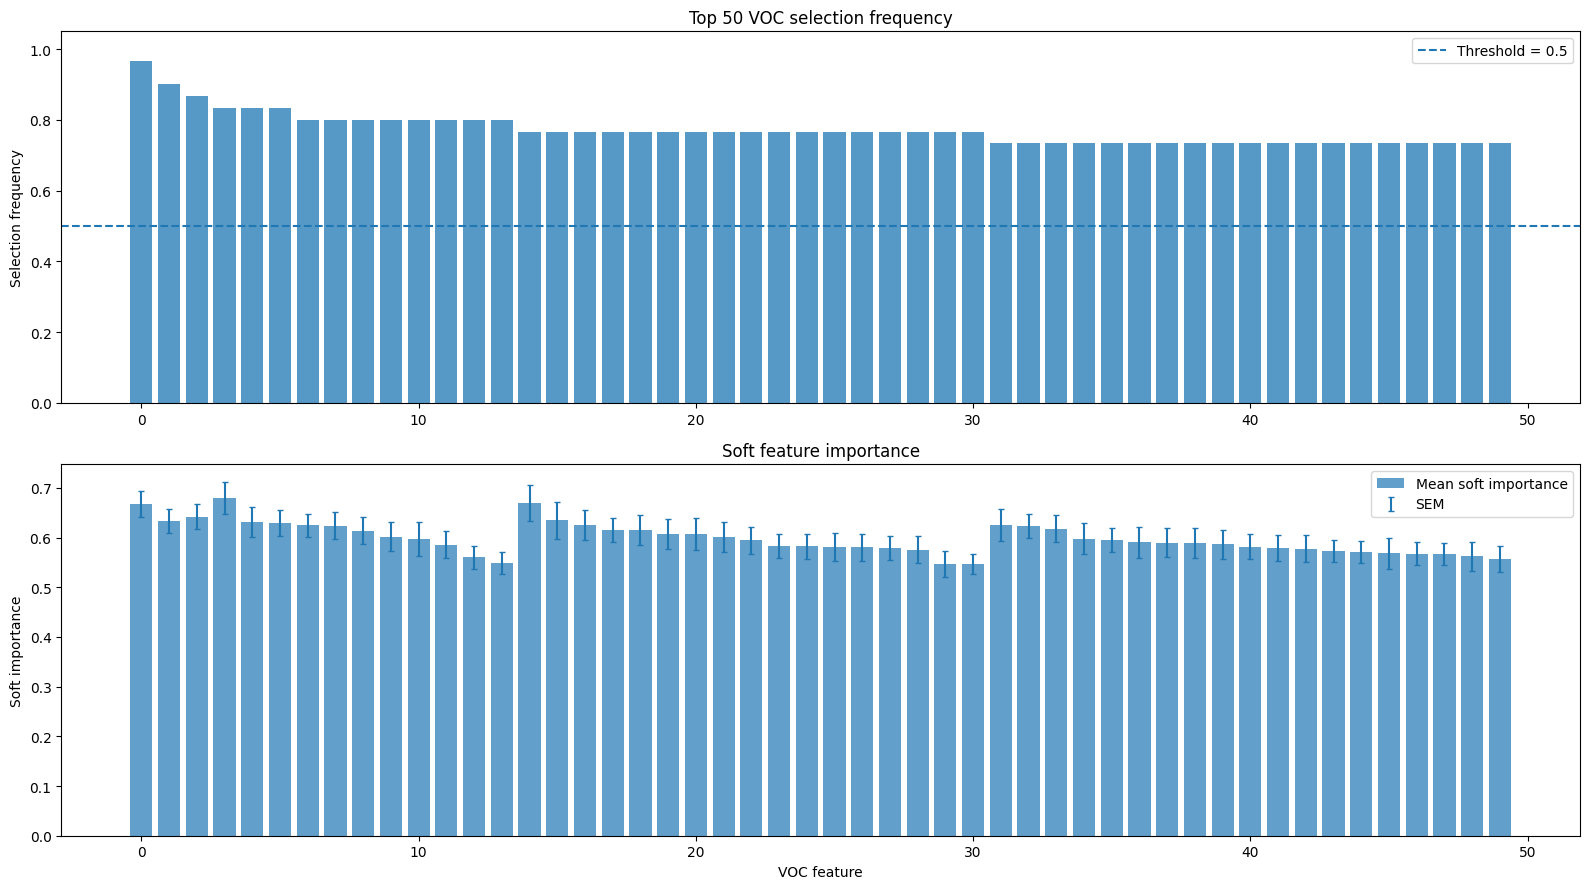

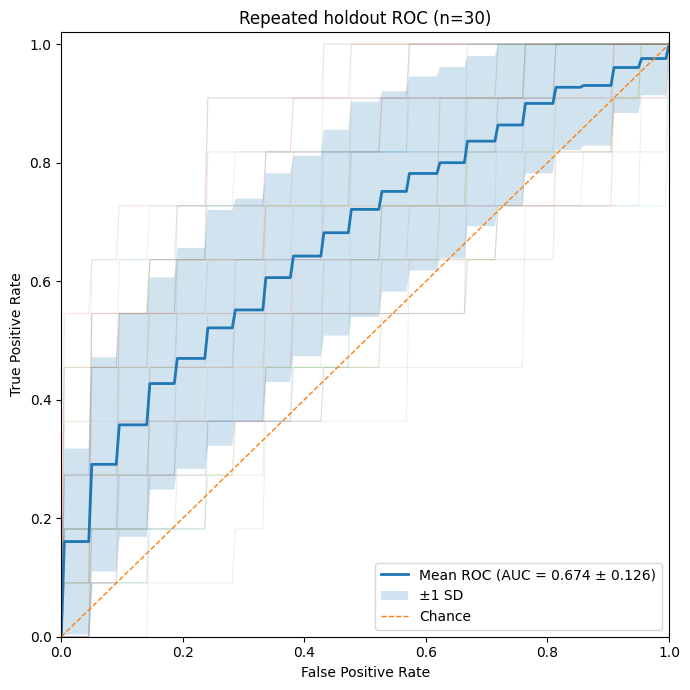


Final report: 30 repeated holdout experiments
------------------------------------------------------------------------
Metric                    Mean                      95% CI
Sensitivity              0.576              [0.495, 0.657]
Specificity              0.679              [0.598, 0.760]
PPV                      0.533              [0.472, 0.595]
NPV                      0.766              [0.733, 0.798]
Accuracy                 0.644              [0.603, 0.685]
Balanced_Accuracy        0.628              [0.594, 0.661]
F1                       0.517              [0.470, 0.563]
AUC                      0.674              [0.626, 0.722]
------------------------------------------------------------------------
平均入选特征数：437.1
最终稳定 VOC 数：602
结果目录：/home/liuxy/a-projects/BPD_jj/result/1+2_vs_3_lambda_001_formal


In [9]:
# ============================================================
# 正式实验 1：Baseline，sparsity_lambda = 1e-3
# ============================================================

summary_base_formal, repeat_base_formal, feature_base_formal, panel_base_formal = experiment(
    data_path="./data/voc_dataset_1+2_vs_3.mat",
    output_dir="./result/1+2_vs_3_lambda_001_formal",

    num_cluster=3,

    experiment_repeats=30,
    repeats=3,
    epochs=100,

    batch_size=16,
    outer_test_size=0.20,
    inner_val_size=0.25,

    num_blocks=2,
    head_dim=64,

    learning_rate_logist=1e-4,
    learning_rate_classifier=3e-4,

    weight_decay_logist=1e-4,
    weight_decay_classifier=1e-3,

    sparsity_lambda=1e-3,

    temp_start=1.0,
    temp_end=0.5,

    patience=30,
    seed=42,
    panel_threshold=0.5,
)

数据读取完成
------------------------------------------------------------
样本数：159
特征数：780
类别数量： {np.int64(0): np.int64(106), np.int64(1): np.int64(53)}


Outer repeats:   0%|          | 0/30 [00:00<?, ?it/s]

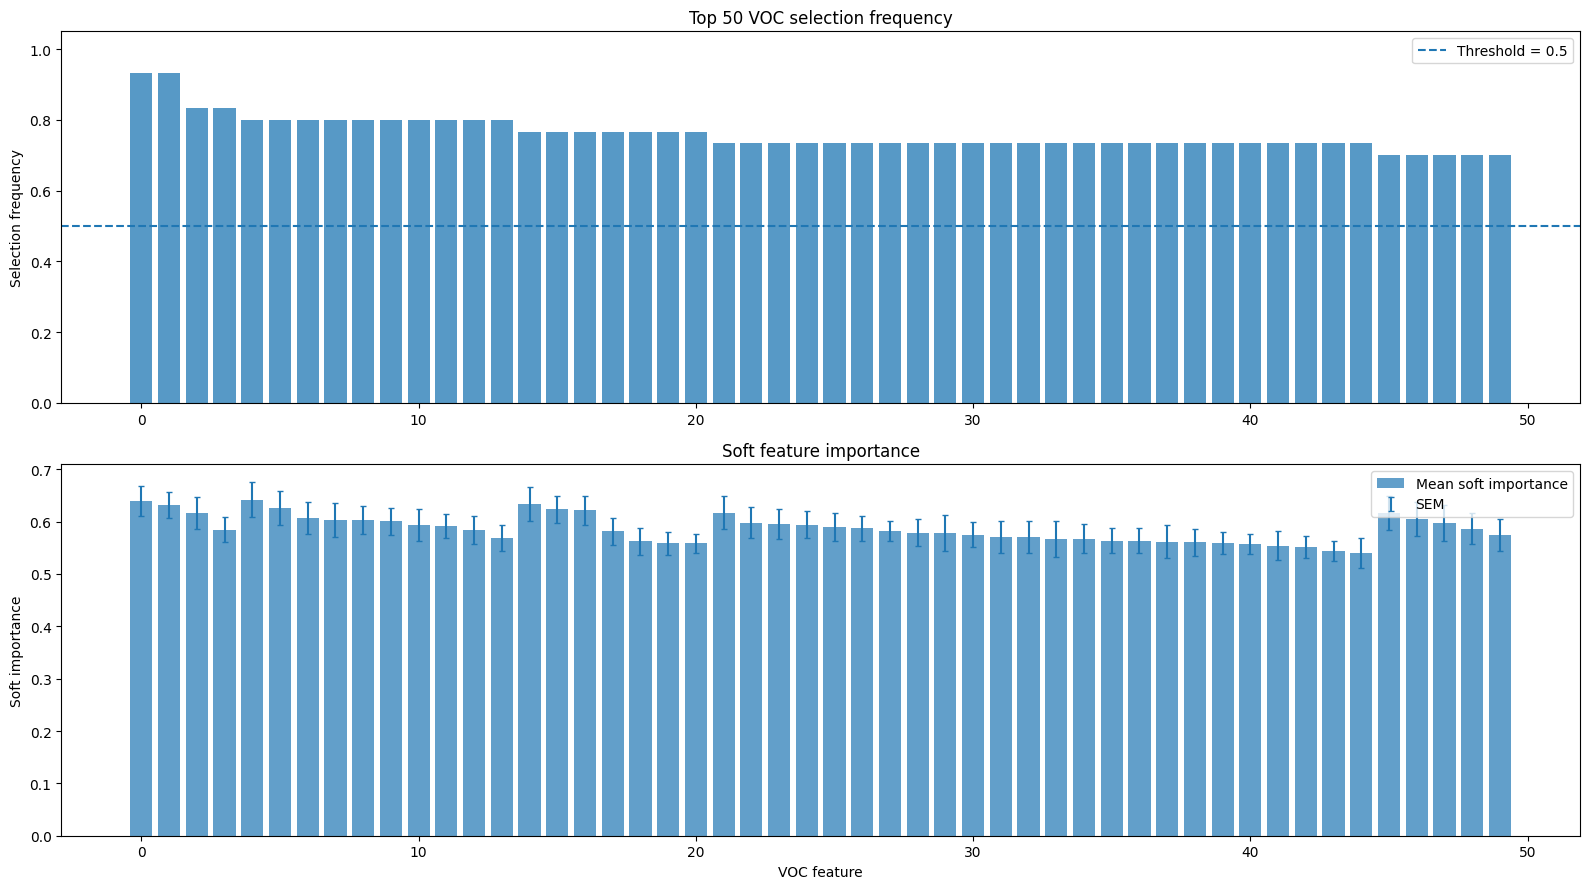

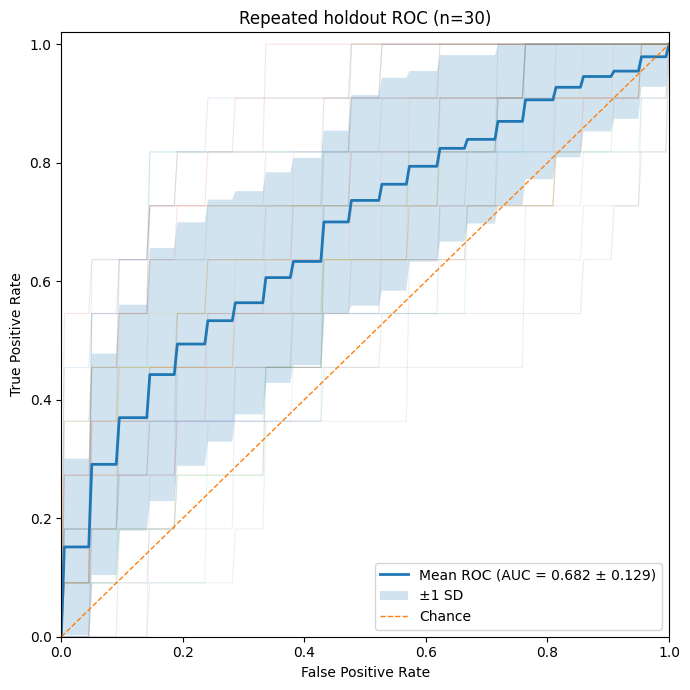


Final report: 30 repeated holdout experiments
------------------------------------------------------------------------
Metric                    Mean                      95% CI
Sensitivity              0.533              [0.443, 0.623]
Specificity              0.710              [0.640, 0.779]
PPV                      0.509              [0.463, 0.556]
NPV                      0.757              [0.722, 0.791]
Accuracy                 0.649              [0.612, 0.685]
Balanced_Accuracy        0.621              [0.585, 0.658]
F1                       0.489              [0.430, 0.548]
AUC                      0.682              [0.633, 0.731]
------------------------------------------------------------------------
平均入选特征数：427.1
最终稳定 VOC 数：564
结果目录：/home/liuxy/a-projects/BPD_jj/result/1+2_vs_3_lambda_010_formal


In [10]:
# ============================================================
# 正式实验 2：Candidate C，sparsity_lambda = 1e-2
# ============================================================

summary_010_formal, repeat_010_formal, feature_010_formal, panel_010_formal = experiment(
    data_path="./data/voc_dataset_1+2_vs_3.mat",
    output_dir="./result/1+2_vs_3_lambda_010_formal",

    num_cluster=3,

    experiment_repeats=30,
    repeats=3,
    epochs=100,

    batch_size=16,
    outer_test_size=0.20,
    inner_val_size=0.25,

    num_blocks=2,
    head_dim=64,

    learning_rate_logist=1e-4,
    learning_rate_classifier=3e-4,

    weight_decay_logist=1e-4,
    weight_decay_classifier=1e-3,

    sparsity_lambda=1e-2,

    temp_start=1.0,
    temp_end=0.5,

    patience=30,
    seed=42,
    panel_threshold=0.5,
)

In [11]:
# ============================================================
# 正式结果对比
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon


formal_experiments = {
    "Baseline_lambda_001": Path(
        "./result/1+2_vs_3_lambda_001_formal"
    ),
    "Candidate_lambda_010": Path(
        "./result/1+2_vs_3_lambda_010_formal"
    ),
}


comparison_rows = []

for experiment_name, folder in formal_experiments.items():

    summary_df_temp = pd.read_csv(
        folder / "metrics_summary.csv"
    )

    repeat_df_temp = pd.read_csv(
        folder / "metrics_per_repeat.csv"
    )

    panel_df_temp = pd.read_csv(
        folder / "selected_voc_panel.csv"
    )

    metric_mean = summary_df_temp.set_index(
        "Metric"
    )["Mean"]

    metric_std = summary_df_temp.set_index(
        "Metric"
    )["Std"]

    comparison_rows.append({
        "Experiment": experiment_name,

        "Accuracy_Mean": metric_mean.get(
            "Accuracy",
            np.nan,
        ),

        "Accuracy_Std": metric_std.get(
            "Accuracy",
            np.nan,
        ),

        "F1_Mean": metric_mean.get(
            "F1",
            np.nan,
        ),

        "F1_Std": metric_std.get(
            "F1",
            np.nan,
        ),

        "AUC_Mean": metric_mean.get(
            "AUC",
            np.nan,
        ),

        "AUC_Std": metric_std.get(
            "AUC",
            np.nan,
        ),

        "Sensitivity": metric_mean.get(
            "Sensitivity",
            np.nan,
        ),

        "Specificity": metric_mean.get(
            "Specificity",
            np.nan,
        ),

        "Mean_Selected_Features": repeat_df_temp[
            "Selected_Features"
        ].mean(),

        "Stable_VOC_Count": len(
            panel_df_temp
        ),
    })


formal_comparison_df = pd.DataFrame(
    comparison_rows
)

display(formal_comparison_df)

formal_comparison_df.to_csv(
    "./result/formal_lambda_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "正式对比表已保存："
    "./result/formal_lambda_comparison.csv"
)

,Experiment,Accuracy_Mean,Accuracy_Std,F1_Mean,F1_Std,AUC_Mean,AUC_Std,Sensitivity,Specificity,Mean_Selected_Features,Stable_VOC_Count
0,Baseline_lambda_001,0.643750,0.109675,0.516831,0.124150,0.674170,0.127788,0.575758,0.679365,437.133333,602
1,Candidate_lambda_010,0.648958,0.097684,0.489126,0.158577,0.682107,0.131116,0.533333,0.709524,427.066667,564


正式对比表已保存：./result/formal_lambda_comparison.csv


In [ ]:
# ============================================================
# Baseline 与 Candidate 的逐次配对检验
# ============================================================

base_repeat = pd.read_csv(
    "./result/1+2_vs_3_lambda_001_formal/"
    "metrics_per_repeat.csv"
)

candidate_repeat = pd.read_csv(
    "./result/1+2_vs_3_lambda_010_formal/"
    "metrics_per_repeat.csv"
)


paired_rows = []

for metric in [
    "Accuracy",
    "F1",
    "AUC",
    "Sensitivity",
    "Specificity",
    "Selected_Features",
]:

    base_values = base_repeat[
        metric
    ].to_numpy(dtype=float)

    candidate_values = candidate_repeat[
        metric
    ].to_numpy(dtype=float)

    differences = (
        candidate_values
        - base_values
    )

    try:
        statistic, p_value = wilcoxon(
            candidate_values,
            base_values,
            zero_method="wilcox",
            alternative="two-sided",
        )
    except ValueError:
        statistic = np.nan
        p_value = np.nan

    paired_rows.append({
        "Metric": metric,

        "Baseline_Mean": np.mean(
            base_values
        ),

        "Candidate_Mean": np.mean(
            candidate_values
        ),

        "Candidate_Minus_Baseline": np.mean(
            differences
        ),

        "Wilcoxon_Statistic": statistic,

        "P_Value": p_value,
    })


paired_test_df = pd.DataFrame(
    paired_rows
)

display(paired_test_df)

paired_test_df.to_csv(
    "./result/formal_paired_test.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "配对检验结果已保存："
    "./result/formal_paired_test.csv"
)